In [14]:
"""
Classifier trained on the 60GeV runs with bias as input feature
"""

'\nClassifier trained on the 60GeV runs with bias as input feature\n'

In [24]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re
import copy
import uproot
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, confusion_matrix
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, Subset


def find_project_root(marker="Data", start=None):
    """Walk up from `start` (default: cwd) until we find a directory containing `marker`."""
    p = (start or Path.cwd()).resolve()
    for candidate in [p, *p.parents]:
        if (candidate / marker).is_dir():
            return candidate
    raise FileNotFoundError(f"Could not find '{marker}' starting from {p}")

PROJECT_ROOT = find_project_root("Data")
DATA_DIR     = PROJECT_ROOT / "Data"
LABELS_CSV   = DATA_DIR / "runs.csv"
print("project root:", PROJECT_ROOT)


project root: /Users/prometheus/Documents/Python/ML_FoCal_FinalProject


In [16]:
# data loading
labels_df = pd.read_csv(LABELS_CSV)
# Keep only the 60 GeV runs with non-zero bias (the new e/h dataset).
runs_df = labels_df.query("energy_GeV == 60 and bias_V > 0").copy()
print("runs to load:")
print(runs_df.to_string(index=False))

def find_root_file(run, data_dir=DATA_DIR):
    """Match either RunXXXX.root or RunXXX_EventMatch.root naming."""
    candidates = list(data_dir.glob(f"Run{run}*.root")) + list(data_dir.glob(f"Run{run:04d}*.root"))
    if not candidates:
        raise FileNotFoundError(f"No ROOT file for run {run}")
    return candidates[0]

val_chunks, run_ids, parts, biases = [], [], [], []
for _, row in runs_df.iterrows():
    f = find_root_file(int(row["run"]))
    t = uproot.open(f)["data_tree"]
    n = t.num_entries

    a0 = t["val0_list_0"].array(library="np").reshape(-1, 38, 64)
    a1 = t["val0_list_1"].array(library="np").reshape(-1, 38, 64)
    val_chunks.append(np.stack([a0, a1], axis=1))

    run_ids.append(np.full(n, int(row["run"]),     dtype=np.int32))
    parts.append(  np.full(n, row["particle"],     dtype="U1"))
    biases.append( np.full(n, int(row["bias_V"]),  dtype=np.int32))
    print(f"  Run{row.run:03d}: {n:6d} events  ({row.particle}, {row.bias_V}V)")

val0     = np.concatenate(val_chunks, axis=0)
run_id   = np.concatenate(run_ids)
particle = np.concatenate(parts)
bias_v   = np.concatenate(biases)
del val_chunks, run_ids, parts, biases

print(f"\ntotal events: {val0.shape[0]}  shape: {val0.shape}  ({val0.nbytes / 1e9:.2f} GB)")


runs to load:
 run  energy_GeV particle  bias_V
 577          60        h      43
 578          60        h      43
 579          60        h      45
 580          60        h      45
 603          60        e      45
 604          60        e      45
 605          60        e      43
 606          60        e      43
 607          60        e      43
  Run577:  17621 events  (h, 43V)
  Run578:  22362 events  (h, 43V)
  Run579:  20390 events  (h, 45V)
  Run580:  19992 events  (h, 45V)
  Run603:   3432 events  (e, 45V)
  Run604:  10275 events  (e, 45V)
  Run605:  17010 events  (e, 43V)
  Run606:  18581 events  (e, 43V)
  Run607:  17227 events  (e, 43V)

total events: 146890  shape: (146890, 2, 38, 64)  (2.86 GB)


### Data shape

Loaded as `val0` with shape `(N, 2, 38, 64)`:

| Dim | Size | Meaning |
|-----|------|---------|
| 0   | N    | event index (one event = one trigger) |
| 1   | 2    | detector halves: `h0`, `h1` |
| 2   | 38   | chips per half |
| 3   | 64   | readout channels per chip |

Parallel label arrays of length N: `run_id`, `particle` (`'e'`/`'h'`), `bias_v` (43/45).

The bias channel that turns this into `(N, 3, 38, 64)` is added later, after pedestal normalization, before training.


val0 shape: (146890, 2, 38, 64)  dtype: uint32
value range: 0 .. 1023
mean: 102.0  nonzero fraction: 0.974

events per (particle, bias):
                 n_events  n_runs
particle bias_V                  
e        43         52818       3
         45         13707       2
h        43         39983       2
         45         40382       2


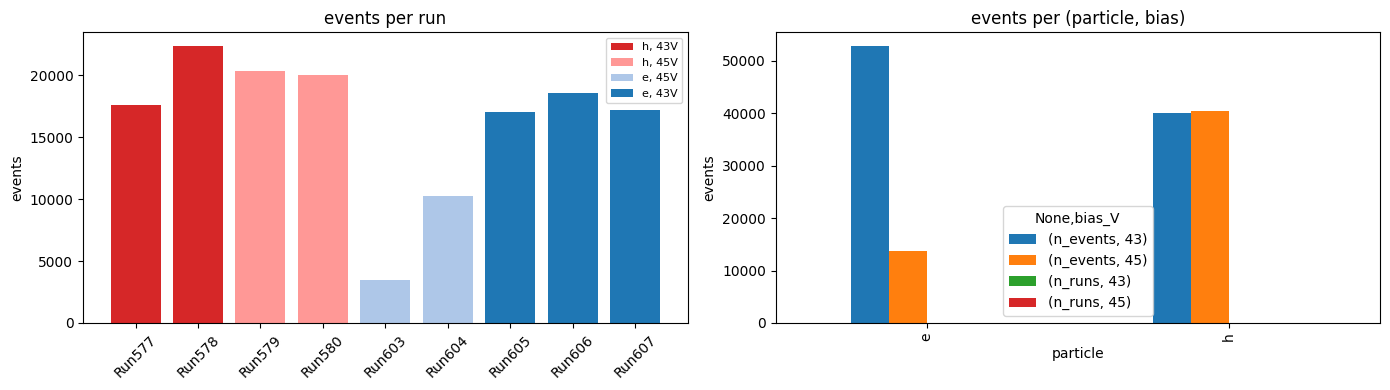

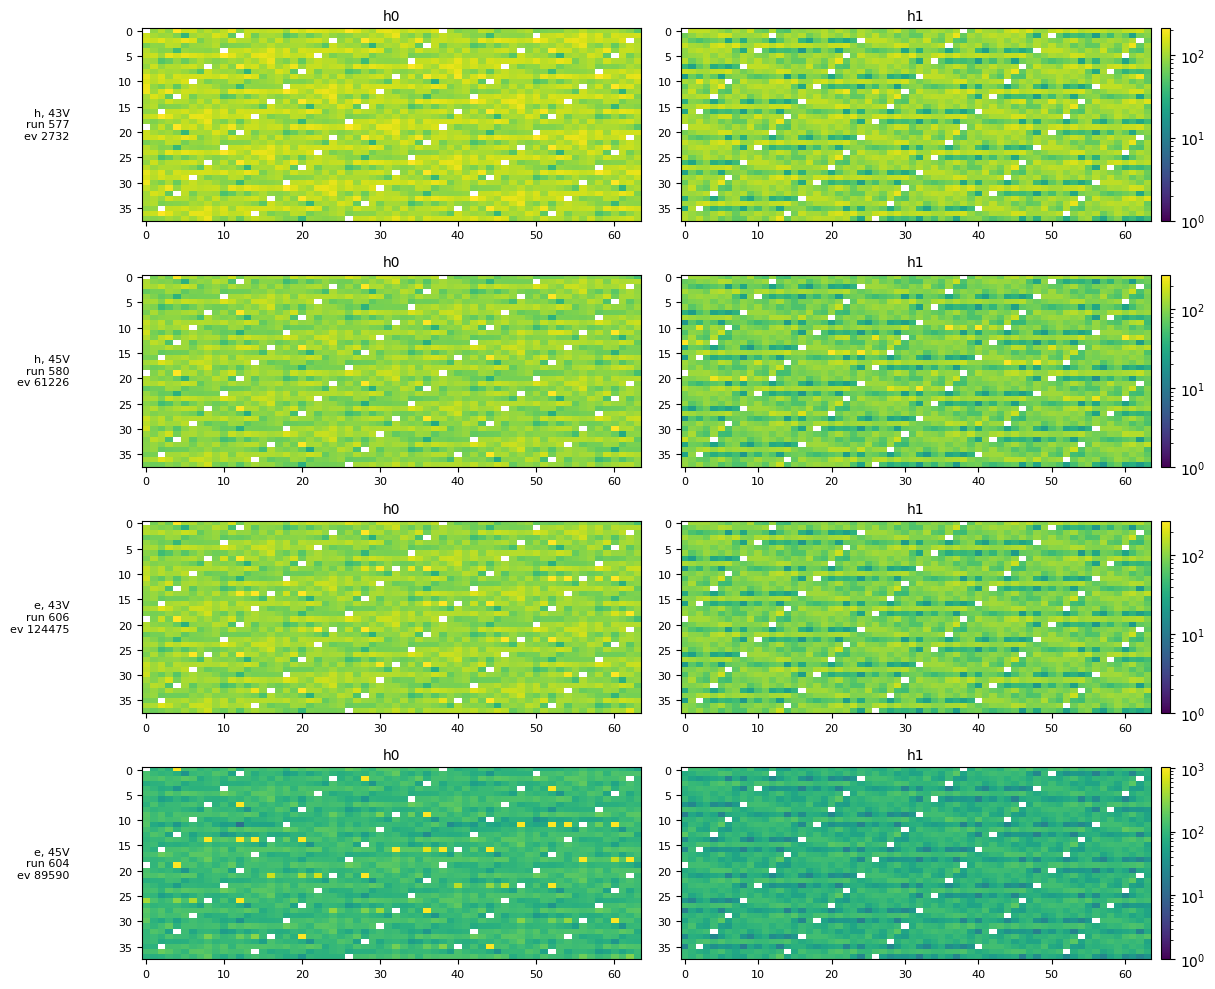

In [17]:
# Visualisation of the data (size and type and so on)
print(f"val0 shape: {val0.shape}  dtype: {val0.dtype}")
print(f"value range: {val0.min()} .. {val0.max()}")
print(f"mean: {val0.mean():.1f}  nonzero fraction: {(val0 > 0).mean():.3f}")

# Counts per (particle, bias) cell
summary = (pd.DataFrame({"particle": particle, "bias_V": bias_v, "run": run_id})
           .groupby(["particle", "bias_V"])
           .agg(n_events=("run", "size"), n_runs=("run", "nunique")))
print("\nevents per (particle, bias):")
print(summary)

# Bar chart: events per run, colored by (particle, bias)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
df = pd.DataFrame({"run": run_id, "particle": particle, "bias_V": bias_v})
counts = df.groupby(["run", "particle", "bias_V"]).size().reset_index(name="n")
colors = {("e", 43): "#1f77b4", ("e", 45): "#aec7e8",
          ("h", 43): "#d62728", ("h", 45): "#ff9896"}
for (_, row), x in zip(counts.iterrows(), range(len(counts))):
    ax[0].bar(x, row.n, color=colors[(row.particle, row.bias_V)],
              label=f"{row.particle}, {row.bias_V}V")
ax[0].set_xticks(range(len(counts)))
ax[0].set_xticklabels([f"Run{r:03d}" for r in counts.run], rotation=45)
ax[0].set_ylabel("events"); ax[0].set_title("events per run")
# Dedupe legend
handles, labels = ax[0].get_legend_handles_labels()
seen = {}
for h, l in zip(handles, labels): seen.setdefault(l, h)
ax[0].legend(seen.values(), seen.keys(), fontsize=8)

# Stacked: events per (particle, bias)
summary.unstack("bias_V").plot.bar(ax=ax[1], stacked=False)
ax[1].set_ylabel("events"); ax[1].set_title("events per (particle, bias)")
plt.tight_layout(); plt.show()

# One example event per (particle, bias) cell -- both halves
from matplotlib.colors import LogNorm
groups = [("h", 43), ("h", 45), ("e", 43), ("e", 45)]
fig, ax = plt.subplots(len(groups), 2, figsize=(12, 2.5 * len(groups)), squeeze=False)
rng = np.random.RandomState(0)
for gi, (p, b) in enumerate(groups):
    mask = (particle == p) & (bias_v == b)
    idx  = rng.choice(np.where(mask)[0])
    ev   = val0[idx]
    vmax = max(int(np.percentile(ev, 99.5)), 2)
    for h in range(2):
        im = ax[gi, h].imshow(ev[h], aspect="auto", cmap="viridis",
                              norm=LogNorm(vmin=1, vmax=vmax))
        ax[gi, h].set_title(f"h{h}", fontsize=10)
        ax[gi, h].tick_params(labelsize=8)
    plt.colorbar(im, ax=ax[gi, 1], fraction=0.04, pad=0.02)
    ax[gi, 0].set_ylabel(f"{p}, {b}V\nrun {run_id[idx]}\nev {idx}",
                         rotation=0, ha="right", va="center", labelpad=35, fontsize=8)
plt.tight_layout(); plt.subplots_adjust(left=0.10); plt.show()


In [18]:
""" Pedestal normalization (computed separately per bias voltage)
For each bias, take the quietest 50% of events by total ADC -- those are mostly noise/pedestal events. 
Use them to compute per-channel mean and std. Apply z-score normalization to all events of that bias.
"""

event_sum = val0.sum(axis=(1, 2, 3))

pedestals = {}  # bias -> (mean (2,38,64), std (2,38,64))
for b in np.unique(bias_v):
    in_bias = bias_v == b
    cutoff  = np.percentile(event_sum[in_bias], 50)
    quiet   = in_bias & (event_sum < cutoff)
    mean    = val0[quiet].mean(axis=0).astype(np.float32)
    std     = val0[quiet].std(axis=0).astype(np.float32)
    pedestals[int(b)] = (mean, std)
    print(f"bias {b}V: {quiet.sum():6d} quiet events used  "
          f"mean ADC {mean.min():.1f}..{mean.max():.1f}  "
          f"avg std {std.mean():.2f}")

# Apply normalization (in place per-bias slice to avoid building a 2x-size copy)
val0_norm = np.empty(val0.shape, dtype=np.float32)
for b, (mean, std) in pedestals.items():
    m = bias_v == b
    val0_norm[m] = (val0[m].astype(np.float32) - mean) / (std + 1e-3)

print(f"\nnormalized: shape={val0_norm.shape}  dtype={val0_norm.dtype}  "
      f"memory={val0_norm.nbytes / 1e9:.2f} GB")
print(f"mean: {val0_norm.mean():+.3f}  (should be ~0 since most events are quiet)")
print(f"std : {val0_norm.std():.3f}  (close to 1 if normalization is sane)")


bias 43V:  46394 quiet events used  mean ADC 0.0..1023.0  avg std 3.14
bias 45V:  27042 quiet events used  mean ADC 0.0..1023.0  avg std 5.27

normalized: shape=(146890, 2, 38, 64)  dtype=float32  memory=2.86 GB
mean: +0.059  (should be ~0 since most events are quiet)
std : 1.229  (close to 1 if normalization is sane)


In [19]:
"""
Build the model input tensor and 3-way train / val / test split.

Input shape: (N, 3, 38, 64)
  - channels 0,1: pedestal-normalized detector halves (val0_norm)
  - channel  2:  broadcasted bias indicator (43V -> -1, 45V -> +1)
Labels: int64 (N,), 0 = hadron, 1 = electron.

Splits, all stratified on (particle, bias):
  - train (70%): fit model weights
  - val   (15%): early stopping and monitoring during training
  - test  (15%): final per-event evaluation. Looked at ONCE at the end --
                 never used to make any modeling decision.

The per-run holdout sanity check (model evaluated on whole runs never seen
during training) comes later as a separate, independent evaluation.
"""

# 3-channel input: 2 normalized halves + 1 bias channel
bias_norm = (bias_v.astype(np.float32) - 44.0)  # 43 -> -1, 45 -> +1
bias_ch   = np.broadcast_to(bias_norm[:, None, None, None],
                            (len(val0_norm), 1, 38, 64)).astype(np.float32)
x_tensor  = np.concatenate([val0_norm, bias_ch], axis=1)
y_tensor  = (particle == "e").astype(np.int64)

print(f"x: {x_tensor.shape}  {x_tensor.nbytes / 1e9:.2f} GB")
print(f"y: {y_tensor.shape}  label counts: "
      f"{dict(zip(['h', 'e'], np.bincount(y_tensor)))}")

# Stratification key combines particle and bias so each cell is represented in
# all three splits in the same proportion as the full dataset
strat = np.array([f"{p}_{b}" for p, b in zip(particle, bias_v)])

# First split: separate off 15% for the test set
idx_trainval, idx_test = train_test_split(
    np.arange(len(x_tensor)),
    test_size=0.15,
    stratify=strat,
    random_state=0,
)
# Second split: from the remaining 85%, take ~17.6% as val -> 15% of the whole
idx_train, idx_val = train_test_split(
    idx_trainval,
    test_size=0.15 / 0.85,
    stratify=strat[idx_trainval],
    random_state=0,
)
print(f"\nsplit sizes:  train {len(idx_train)}  val {len(idx_val)}  test {len(idx_test)}")
for name, idx in [("  train", idx_train), ("  val  ", idx_val), ("  test ", idx_test)]:
    counts = {k: int((strat[idx] == k).sum()) for k in sorted(np.unique(strat))}
    print(f"{name}: {counts}")

# Wrap as TensorDataset + Subset for each split
ds = TensorDataset(torch.from_numpy(x_tensor), torch.from_numpy(y_tensor))
train_ds = Subset(ds, idx_train)
val_ds   = Subset(ds, idx_val)
test_ds  = Subset(ds, idx_test)  # set aside, do not peek

BATCH = 256
train_loader = DataLoader(train_ds, batch_size=BATCH,     shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH * 2, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH * 2, shuffle=False, num_workers=0)

# Smoke test
xb, yb = next(iter(train_loader))
print(f"\nbatch x: {tuple(xb.shape)} {xb.dtype}   y: {tuple(yb.shape)} {yb.dtype}")
print(f"bias channel values in batch: {torch.unique(xb[:, 2]).tolist()}")


x: (146890, 3, 38, 64)  4.29 GB
y: (146890,)  label counts: {'h': np.int64(80365), 'e': np.int64(66525)}

split sizes:  train 102822  val 22034  test 22034
  train: {np.str_('e_43'): 36972, np.str_('e_45'): 9595, np.str_('h_43'): 27988, np.str_('h_45'): 28267}
  val  : {np.str_('e_43'): 7923, np.str_('e_45'): 2056, np.str_('h_43'): 5997, np.str_('h_45'): 6058}
  test : {np.str_('e_43'): 7923, np.str_('e_45'): 2056, np.str_('h_43'): 5998, np.str_('h_45'): 6057}

batch x: (256, 3, 38, 64) torch.float32   y: (256,) torch.int64
bias channel values in batch: [-1.0, 1.0]


### CNN classifier architecture

About 26K parameters. Input shape `(B, 3, 38, 64)`, output 2 logits.

| Layer | Output shape | Notes |
|-------|-------------|-------|
| Input | `(B, 3, 38, 64)` | 2 normalized halves + 1 bias channel |
| Conv2d(3→16, 3×3) + BatchNorm + ReLU | `(B, 16, 38, 64)` | |
| Conv2d(16→32, 3×3, stride 2) + BN + ReLU | `(B, 32, 19, 32)` | downsample |
| Conv2d(32→64, 3×3, stride 2) + BN + ReLU | `(B, 64, 10, 16)` | downsample |
| AdaptiveAvgPool2d(1) + Flatten | `(B, 64)` | translation invariance |
| Dropout(0.3) + Linear(64→32) + ReLU | `(B, 32)` | |
| Dropout(0.3) + Linear(32→2) | `(B, 2)` | logits — apply softmax for probabilities |

**Three design choices:**

Global average pooling instead of flatten + big Fully Connected layer. bakes in translation invariance (a shower at chip 5 vs chip 25 gets pooled to roughly the same feature).

BatchNorm after every conv for stable training and implicit regularization.

Dropout 0.3 in the head to discourage the model from memorizing event level quirks.


In [20]:
"""
CNN classifier for hadron vs electron events.

Architecture:
- 3 conv layers with BatchNorm + ReLU; two stride-2 layers downsample 38x64 -> 10x16
- Global average pool reduces (64, 10, 16) -> (64,) so the head sees a fixed-size
  feature vector regardless of where in the grid the shower landed (translation invariance)
- Small MLP head with dropout, outputs 2 logits (hadron, electron)

Input:  (B, 3, 38, 64) -- 2 normalized halves + 1 bias channel
Output: (B, 2) class logits; apply softmax for probabilities
"""

class CNNClassifier(nn.Module):
    def __init__(self, n_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),  # 38x64 -> 19x32
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),  # 19x32 -> 10x16
            nn.BatchNorm2d(64),
            nn.ReLU(),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),  # (B, 64, 1, 1)
            nn.Flatten(),             # (B, 64)
            nn.Dropout(0.3),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, n_classes),
        )

    def forward(self, x):
        return self.head(self.features(x))


device = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available()
          else "cpu")
model = CNNClassifier().to(device)

# Sanity check: forward pass on a dummy batch matches expected shape
with torch.no_grad():
    dummy = torch.zeros(2, 3, 38, 64, device=device)
    out = model(dummy)
    assert out.shape == (2, 2), out.shape
    print(f"output shape ok: {tuple(out.shape)}")

print(f"\ndevice: {device}   params: {sum(p.numel() for p in model.parameters()):,}")
print(model)


output shape ok: (2, 2)

device: mps   params: 25,954
CNNClassifier(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
  )
  (head): Sequential(
    (0): AdaptiveAvgPool2d(output_size=1)
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=2, bias=True)
  )
)


### Training pipeline

What the next cell does, in order:

1. **Optimizer**: `AdamW` with `weight_decay=1e-4`. Adam-style adaptive LR plus correctly-decoupled weight decay for mild regularization.
2. **Loss**: `CrossEntropyLoss` over 2 classes (hadron, electron). Equivalent to BCE with a softmax head.
3. **LR scheduler**: `ReduceLROnPlateau` — halves the learning rate when val loss hasn't improved for `LR_PATIENCE` epochs. Gives the model a smaller step size to escape a plateau before early stopping kicks in.
4. **Per-epoch loop**: full pass over `train_loader`, then evaluation pass over `val_loader`. Logs train/val loss and val accuracy.
5. **Early stopping**: if val loss hasn't improved by `MIN_DELTA` for `PATIENCE` epochs (where `PATIENCE > LR_PATIENCE`), stop and restore best-val-loss weights.
6. **Weight caching**: best weights are saved to `Rasmus/classifier_60GeV.pt`. On next run, loaded from disk unless `RETRAIN = True`.
7. **No test-set access** anywhere in this cell — that's locked behind its own cell at the end of the notebook.


In [21]:
"""
Train the CNN classifier with early stopping and an LR scheduler.

- AdamW(weight_decay=1e-4) + CrossEntropyLoss
- ReduceLROnPlateau halves LR after LR_PATIENCE epochs without improvement
- Early stop if no improvement for PATIENCE epochs (PATIENCE > LR_PATIENCE so
  the scheduler gets a chance to fire before training gives up)
- Best-val-loss weights restored and saved to disk; test set is not touched
"""

MAX_EPOCHS   = 100
PATIENCE     = 12      # epochs without val improvement -> stop training
LR_PATIENCE  = 4       # epochs without val improvement -> halve LR
MIN_DELTA    = 1e-4
LR           = 1e-3
WEIGHT_DECAY = 1e-4
RETRAIN      = False  
CLASSIFIER_WEIGHTS = PROJECT_ROOT / "Rasmus" / "classifier_60GeV.pt"

history = {"train_loss": [], "val_loss": [], "val_acc": [], "lr": []}

if CLASSIFIER_WEIGHTS.exists() and not RETRAIN:
    model.load_state_dict(torch.load(CLASSIFIER_WEIGHTS, map_location=device))
    print(f"loaded cached weights from {CLASSIFIER_WEIGHTS.name} (set RETRAIN=True to override)")
else:
    opt       = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="min", factor=0.5, patience=LR_PATIENCE, min_lr=1e-6,
    )
    loss_fn = nn.CrossEntropyLoss()

    best_val_loss = float("inf")
    best_epoch    = -1
    best_state    = copy.deepcopy(model.state_dict())
    bad_epochs    = 0

    for epoch in range(MAX_EPOCHS):
        # ---- train pass ----
        model.train()
        tr_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = loss_fn(logits, yb)
            opt.zero_grad(); loss.backward(); opt.step()
            tr_loss += loss.item() * xb.size(0)
        tr_loss /= len(train_ds)

        # ---- val pass ----
        model.eval()
        va_loss, correct = 0.0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                va_loss += loss_fn(logits, yb).item() * xb.size(0)
                correct += (logits.argmax(1) == yb).sum().item()
        va_loss /= len(val_ds)
        va_acc   = correct / len(val_ds)

        # ---- scheduler step + bookkeeping ----
        scheduler.step(va_loss)
        cur_lr = opt.param_groups[0]["lr"]

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        history["lr"].append(cur_lr)

        improved = va_loss < best_val_loss - MIN_DELTA
        if improved:
            best_val_loss = va_loss
            best_epoch    = epoch
            best_state    = copy.deepcopy(model.state_dict())
            bad_epochs    = 0
            tag = " *"
        else:
            bad_epochs += 1
            tag = ""
        print(f"epoch {epoch+1:3d}/{MAX_EPOCHS}  "
              f"train={tr_loss:.4f}  val_loss={va_loss:.4f}  val_acc={va_acc:.3f}  "
              f"lr={cur_lr:.1e}  bad={bad_epochs}{tag}")

        if bad_epochs >= PATIENCE:
            print(f"\nearly stop at epoch {epoch+1}: no improvement for {PATIENCE} epochs")
            break

    # Restore best weights and persist them
    model.load_state_dict(best_state)
    torch.save(best_state, CLASSIFIER_WEIGHTS)
    print(f"\nbest val_loss={best_val_loss:.4f}  "
          f"val_acc={history['val_acc'][best_epoch]:.3f} at epoch {best_epoch+1}")
    print(f"saved {CLASSIFIER_WEIGHTS}")


loaded cached weights from classifier_60GeV.pt (set RETRAIN=True to override)


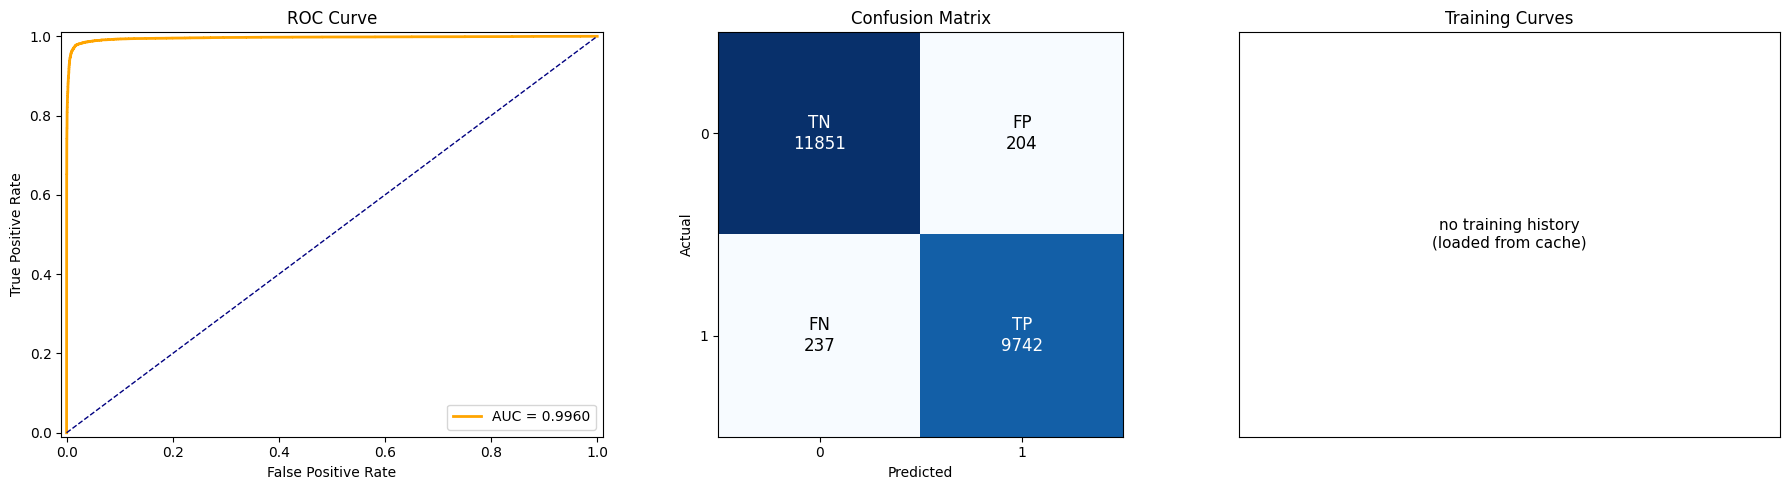

val accuracy:  0.9800
val AUC:       0.9960
confusion matrix (rows=actual, cols=predicted):
      pred=h  pred=e
act=h   11851     204
act=e     237    9742


In [22]:
"""
Evaluate the trained classifier on the validation set.

Three plots side by side:
- ROC curve with AUC for the electron class
- Confusion matrix with TN/FP/FN/TP cells
- Training curves (skipped if model was loaded from cache)

Plus a printed summary: val accuracy, AUC, and the raw confusion matrix.
"""

# Collect val predictions
model.eval()
probs_list, labels_list = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)
        logits = model(xb)
        probs  = torch.softmax(logits, dim=1)[:, 1]  # P(electron)
        probs_list.append(probs.cpu().numpy())
        labels_list.append(yb.numpy())
y_prob = np.concatenate(probs_list)
y_true = np.concatenate(labels_list)
y_pred = (y_prob > 0.5).astype(int)

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc     = auc(fpr, tpr)
cm          = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

# Plot
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# --- ROC ---
ax[0].plot(fpr, tpr, color="orange", lw=2, label=f"AUC = {roc_auc:.4f}")
ax[0].plot([0, 1], [0, 1], "--", color="navy", lw=1)
ax[0].set_xlabel("False Positive Rate"); ax[0].set_ylabel("True Positive Rate")
ax[0].set_title("ROC Curve"); ax[0].legend(loc="lower right")
ax[0].set_xlim(-0.01, 1.01); ax[0].set_ylim(-0.01, 1.01)

# --- Confusion matrix ---
ax[1].imshow(cm, cmap="Blues")
ax[1].set_xticks([0, 1]); ax[1].set_yticks([0, 1])
ax[1].set_xlabel("Predicted"); ax[1].set_ylabel("Actual")
ax[1].set_title("Confusion Matrix")
cell_labels = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        val = cm[i, j]
        ax[1].text(j, i, f"{cell_labels[i][j]}\n{val}", ha="center", va="center",
                   color="white" if val > cm.max() / 2 else "black", fontsize=12)

# --- Training curves (only if we have history) ---
if history["train_loss"]:
    ax[2].plot(history["train_loss"], label="Train")
    ax[2].plot(history["val_loss"],   label="Validation")
    ax[2].set_xlabel("Epoch"); ax[2].set_ylabel("Cross-entropy loss")
    ax[2].set_title("Training Curves"); ax[2].legend()
else:
    ax[2].text(0.5, 0.5, "no training history\n(loaded from cache)",
               ha="center", va="center", transform=ax[2].transAxes, fontsize=11)
    ax[2].set_xticks([]); ax[2].set_yticks([])
    ax[2].set_title("Training Curves")

plt.tight_layout(); plt.show()

# Numerical summary
print(f"val accuracy:  {(y_pred == y_true).mean():.4f}")
print(f"val AUC:       {roc_auc:.4f}")
print(f"confusion matrix (rows=actual, cols=predicted):")
print(f"      pred=h  pred=e")
print(f"act=h  {tn:6d}  {fp:6d}")
print(f"act=e  {fn:6d}  {tp:6d}")


### Grad-CAM: where is the classifier looking?

For each `(particle, bias)` cell, pick a high-confidence *correctly-classified* event and visualize:

1. Input `h0` and `h1` (log-scaled ADC)
2. The Grad-CAM heatmap for the predicted class — bright regions are where the classifier focused

**Interpretation guide:**

- **Tight, compact bright region** → model is locking onto a shower-shaped feature in a specific area. Consistent with real physics.
- **Diffuse / scattered bright regions** → model is using distributed channel-level patterns. Could be real (signature spread across the detector) or could be a run-fingerprint shortcut (specific dead/noisy channels).
- **Bright everywhere or nowhere** → uninformative, or the bias channel is dominating.

Grad-CAM uses the activations of the **last ReLU before the global average pool** (`model.features[-1]`), weighted by the gradients of the predicted-class logit with respect to those activations. Bilinearly upsampled from `10x16` to `38x64`.


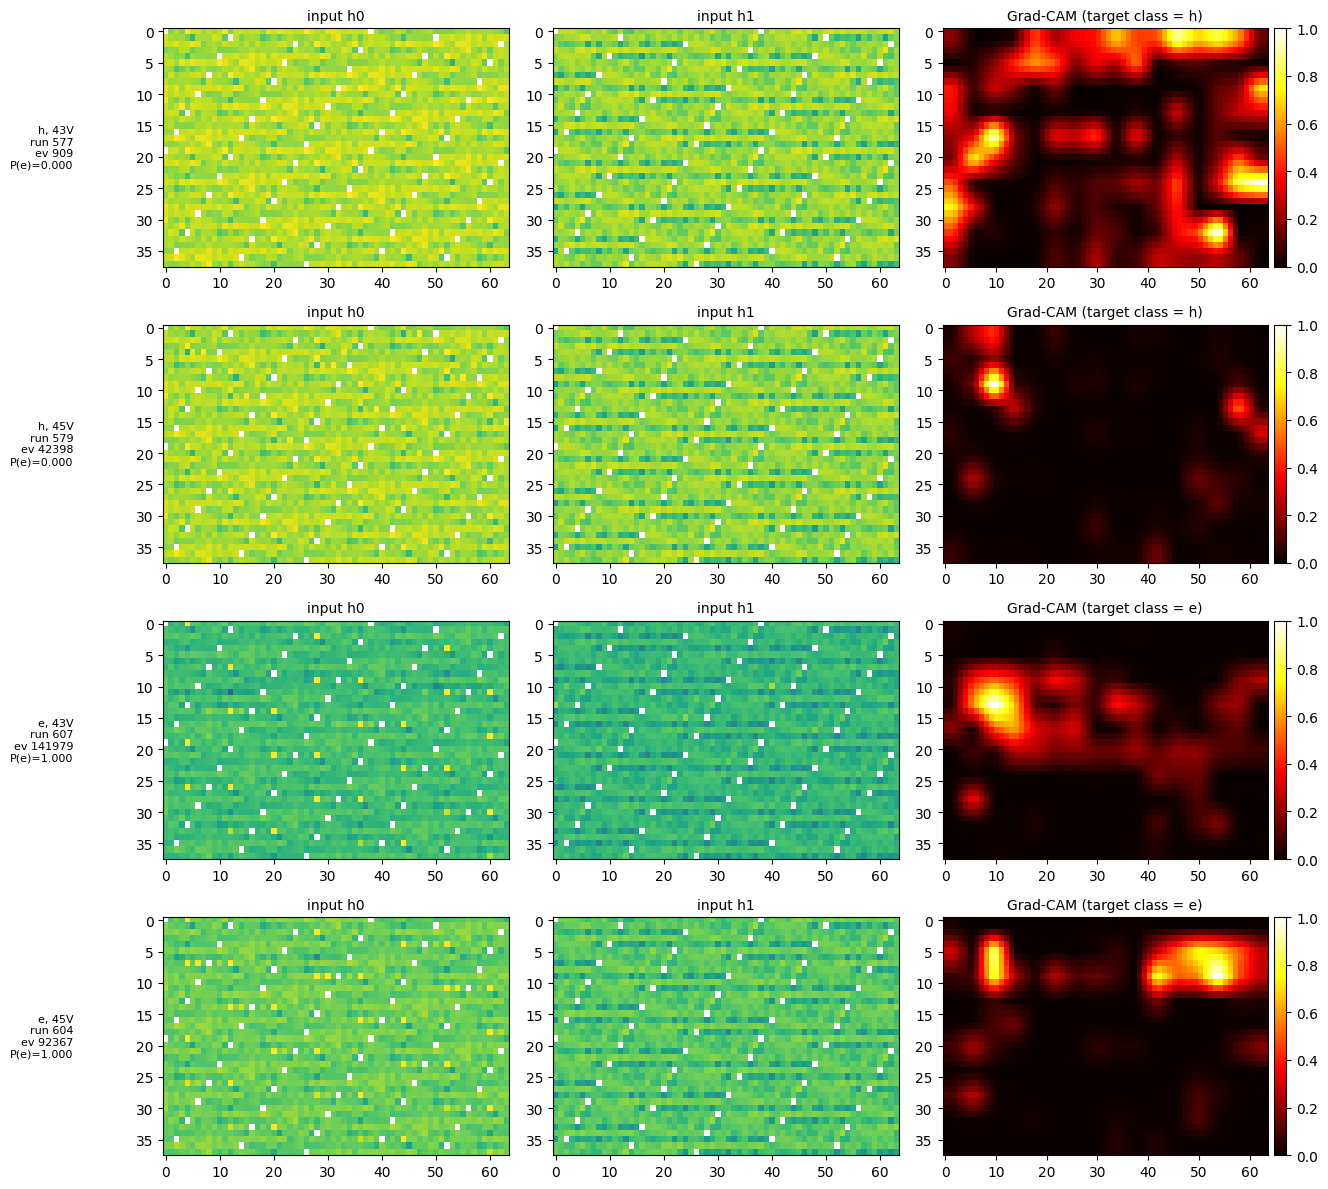

In [25]:
"""
Grad-CAM analysis on high-confidence correctly-classified val events.

Shows input h0, input h1, and the Grad-CAM heatmap (for the predicted class)
side-by-side for one event per (particle, bias) cell. The heatmap is computed
from the last activation map before global pool, weighted by gradients of the
target-class logit, then bilinearly upsampled to input resolution.
"""

from matplotlib.colors import LogNorm

def grad_cam(model, x, target_class, target_module):
    """Grad-CAM heatmap. x: (1, C, H, W). Returns (H, W) numpy in [0, 1]."""
    model.eval()
    cache = {}

    def fwd(_, __, output):
        cache["acts"] = output

    def bwd(_, grad_in, grad_out):
        cache["grads"] = grad_out[0]

    h1 = target_module.register_forward_hook(fwd)
    h2 = target_module.register_full_backward_hook(bwd)
    try:
        logits = model(x)
        score  = logits[0, target_class]
        model.zero_grad()
        score.backward()

        acts    = cache["acts"][0]                   # (C, h, w)
        grads   = cache["grads"][0]                  # (C, h, w)
        weights = grads.mean(dim=(1, 2))             # (C,)
        cam     = (weights[:, None, None] * acts).sum(dim=0)
        cam     = torch.relu(cam)

        cam = F.interpolate(cam[None, None], size=(38, 64),
                            mode="bilinear", align_corners=False)
        cam = cam.squeeze().detach().cpu().numpy()
        return cam / (cam.max() + 1e-9)
    finally:
        h1.remove(); h2.remove()


target_layer = model.features[-1]  # last ReLU before GAP

# Get val probabilities + alignment with val_ds indices
val_indices  = np.asarray(val_ds.indices)
val_particle = particle[val_indices]
val_bias_v   = bias_v[val_indices]
val_y        = y_tensor[val_indices]

model.eval()
val_probs = np.empty(len(val_indices), dtype=np.float32)
cursor = 0
with torch.no_grad():
    for xb, _ in val_loader:
        xb = xb.to(device)
        p = torch.softmax(model(xb), dim=1)[:, 1].cpu().numpy()
        val_probs[cursor:cursor + len(p)] = p
        cursor += len(p)

val_preds   = (val_probs > 0.5).astype(int)
val_correct = val_preds == val_y

# One high-confidence correct event per (particle, bias)
groups = [("h", 43), ("h", 45), ("e", 43), ("e", 45)]
fig, ax = plt.subplots(len(groups), 3, figsize=(13, 3 * len(groups)), squeeze=False)

for gi, (p, b) in enumerate(groups):
    mask = (val_particle == p) & (val_bias_v == b) & val_correct
    if not mask.any():
        for j in range(3):
            ax[gi, j].text(0.5, 0.5, f"no correct {p}/{b}V events",
                           ha="center", va="center", transform=ax[gi, j].transAxes)
            ax[gi, j].set_xticks([]); ax[gi, j].set_yticks([])
        continue

    pred = 1 if p == "e" else 0
    cand_pos = np.where(mask)[0]
    # highest P(target_class) among correct events of this cell
    score = val_probs[cand_pos] if pred == 1 else -val_probs[cand_pos]
    pick = cand_pos[np.argmax(score)]
    orig_idx = val_indices[pick]

    # Compute CAM
    x = torch.from_numpy(x_tensor[orig_idx:orig_idx + 1]).to(device)
    cam = grad_cam(model, x, target_class=pred, target_module=target_layer)

    # Show inputs in raw ADC space (more interpretable than the normalized tensor)
    ev = val0[orig_idx]
    vmax = max(int(np.percentile(ev, 99.5)), 2)
    norm = LogNorm(vmin=1, vmax=vmax)

    ax[gi, 0].imshow(ev[0], aspect="auto", cmap="viridis", norm=norm)
    ax[gi, 0].set_title("input h0", fontsize=10)
    ax[gi, 1].imshow(ev[1], aspect="auto", cmap="viridis", norm=norm)
    ax[gi, 1].set_title("input h1", fontsize=10)
    im = ax[gi, 2].imshow(cam, aspect="auto", cmap="hot", vmin=0, vmax=1)
    ax[gi, 2].set_title(f"Grad-CAM (target class = {'e' if pred==1 else 'h'})", fontsize=10)
    plt.colorbar(im, ax=ax[gi, 2], fraction=0.04, pad=0.02)

    ax[gi, 0].set_ylabel(
        f"{p}, {b}V\nrun {run_id[orig_idx]}\nev {orig_idx}\nP(e)={val_probs[pick]:.3f}",
        rotation=0, ha="right", va="center", labelpad=45, fontsize=8,
    )

plt.tight_layout(); plt.subplots_adjust(left=0.10); plt.show()


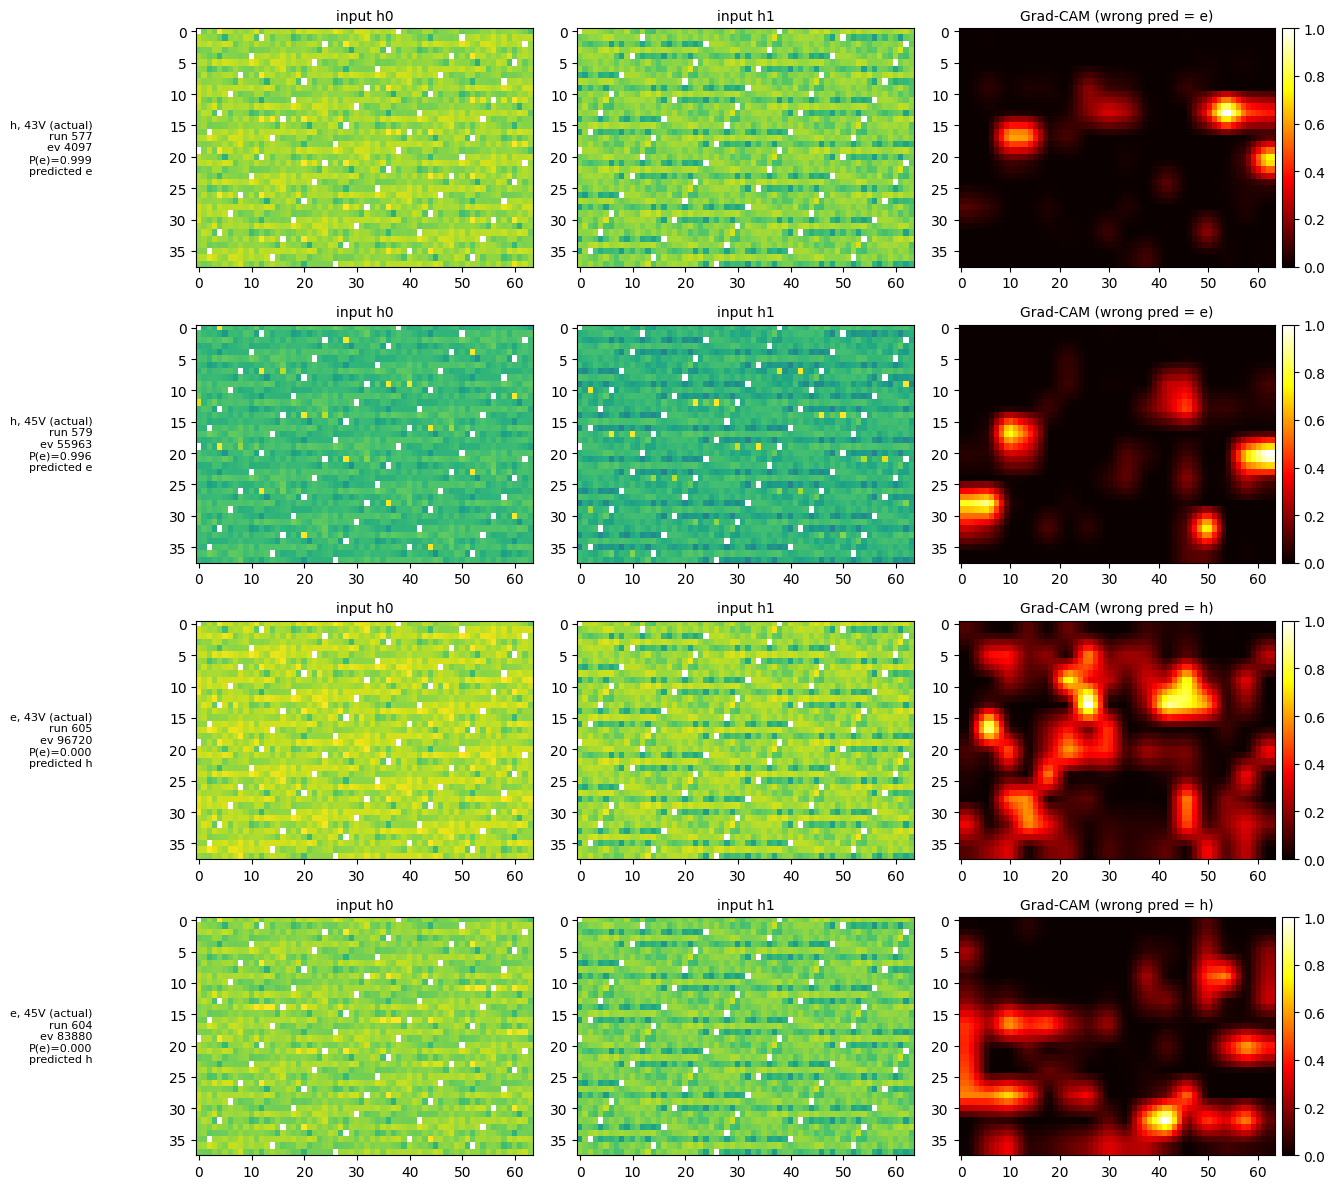

misclassified events per cell:
  h, 43V: 131 / 5997 (2.18%)
  h, 45V: 73 / 6058 (1.21%)
  e, 43V: 151 / 7923 (1.91%)
  e, 45V: 86 / 2056 (4.18%)


In [26]:
"""
Grad-CAM on the *most-confident misclassified* events.

For each (particle, bias) cell, pick the event the model got most wrong
(highest probability assigned to the wrong class) and visualize what the
model was looking at when it made the mistake.

Target class for the CAM is the *predicted* (wrong) class, so the heatmap
shows what convinced the model of the incorrect label.

Interpretation:
- If misclassified-event CAMs look qualitatively like the correct-event CAMs
  for the wrong class, the model is using the same features in both cases --
  it just got confused by an event that happens to look like the other class.
- If they look different (e.g., scattered noise), the model may be reacting
  to a per-event quirk rather than a coherent class feature.
"""

# Reuses val_indices, val_particle, val_bias_v, val_y, val_probs, val_preds,
# val_correct, grad_cam(), and target_layer from the previous cell.

groups = [("h", 43), ("h", 45), ("e", 43), ("e", 45)]
fig, ax = plt.subplots(len(groups), 3, figsize=(13, 3 * len(groups)), squeeze=False)

for gi, (p, b) in enumerate(groups):
    mask = (val_particle == p) & (val_bias_v == b) & (~val_correct)
    if not mask.any():
        for j in range(3):
            ax[gi, j].text(0.5, 0.5, f"no misclassified {p}/{b}V events",
                           ha="center", va="center", transform=ax[gi, j].transAxes)
            ax[gi, j].set_xticks([]); ax[gi, j].set_yticks([])
        continue

    true_class = 1 if p == "e" else 0
    wrong_pred = 1 - true_class  # what the model said instead

    cand_pos = np.where(mask)[0]
    # "Most confidently wrong" = highest probability assigned to wrong_pred class
    if wrong_pred == 1:
        # h actual but model said e -> pick max P(e)
        pick = cand_pos[np.argmax(val_probs[cand_pos])]
    else:
        # e actual but model said h -> pick min P(e)  (= max P(h))
        pick = cand_pos[np.argmin(val_probs[cand_pos])]
    orig_idx = val_indices[pick]

    # CAM for the wrongly-predicted class
    x   = torch.from_numpy(x_tensor[orig_idx:orig_idx + 1]).to(device)
    cam = grad_cam(model, x, target_class=wrong_pred, target_module=target_layer)

    # Inputs in raw ADC space, log scale
    ev = val0[orig_idx]
    vmax = max(int(np.percentile(ev, 99.5)), 2)
    norm = LogNorm(vmin=1, vmax=vmax)

    ax[gi, 0].imshow(ev[0], aspect="auto", cmap="viridis", norm=norm)
    ax[gi, 0].set_title("input h0", fontsize=10)
    ax[gi, 1].imshow(ev[1], aspect="auto", cmap="viridis", norm=norm)
    ax[gi, 1].set_title("input h1", fontsize=10)
    im = ax[gi, 2].imshow(cam, aspect="auto", cmap="hot", vmin=0, vmax=1)
    ax[gi, 2].set_title(f"Grad-CAM (wrong pred = {'e' if wrong_pred==1 else 'h'})", fontsize=10)
    plt.colorbar(im, ax=ax[gi, 2], fraction=0.04, pad=0.02)

    ax[gi, 0].set_ylabel(
        f"{p}, {b}V (actual)\nrun {run_id[orig_idx]}\nev {orig_idx}\n"
        f"P(e)={val_probs[pick]:.3f}\npredicted {'e' if wrong_pred==1 else 'h'}",
        rotation=0, ha="right", va="center", labelpad=55, fontsize=8,
    )

plt.tight_layout(); plt.subplots_adjust(left=0.12); plt.show()

# Numerical summary: error counts per cell
print("misclassified events per cell:")
for p, b in groups:
    n_total = int(((val_particle == p) & (val_bias_v == b)).sum())
    n_wrong = int(((val_particle == p) & (val_bias_v == b) & ~val_correct).sum())
    print(f"  {p}, {b}V: {n_wrong} / {n_total} ({100 * n_wrong / max(n_total, 1):.2f}%)")


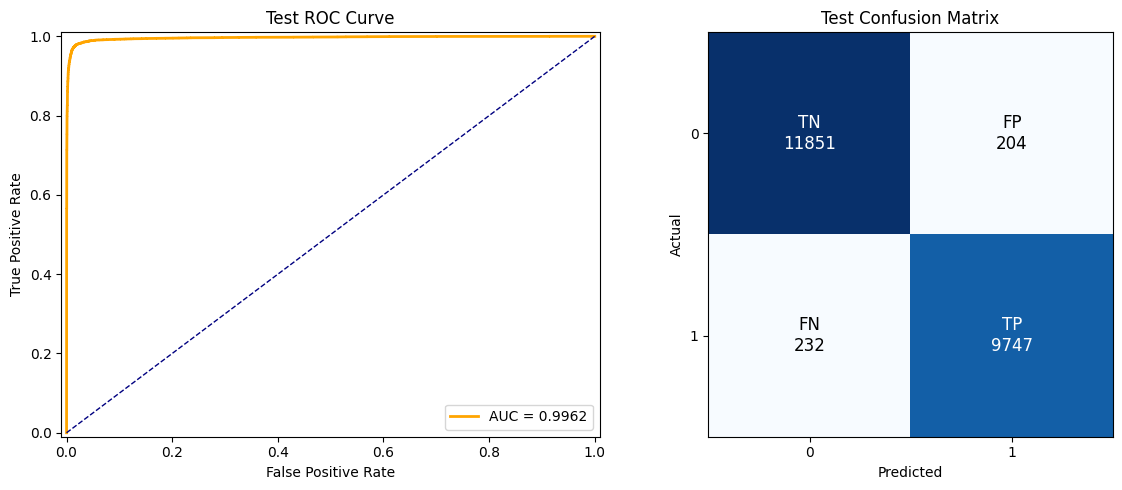

test accuracy:  0.9802
test AUC:       0.9962
confusion matrix (rows=actual, cols=predicted):
      pred=h  pred=e
act=h   11851     204
act=e     232    9747


In [23]:
"""
FINAL test-set evaluation.

The held-out 15% test split, never seen during training and never used for
model selection. Run this ONCE after you're done iterating on the model. If
you run it and then make a change based on what you see, it stops being a
test set and becomes another validation set.

Reports per-event accuracy, ROC + AUC, and confusion matrix on the test set.
"""

# Collect test predictions
model.eval()
probs_list, labels_list = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        probs  = torch.softmax(logits, dim=1)[:, 1]  # P(electron)
        probs_list.append(probs.cpu().numpy())
        labels_list.append(yb.numpy())
y_prob = np.concatenate(probs_list)
y_true = np.concatenate(labels_list)
y_pred = (y_prob > 0.5).astype(int)

fpr, tpr, _   = roc_curve(y_true, y_prob)
roc_auc       = auc(fpr, tpr)
cm            = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# ROC
ax[0].plot(fpr, tpr, color="orange", lw=2, label=f"AUC = {roc_auc:.4f}")
ax[0].plot([0, 1], [0, 1], "--", color="navy", lw=1)
ax[0].set_xlabel("False Positive Rate"); ax[0].set_ylabel("True Positive Rate")
ax[0].set_title("Test ROC Curve"); ax[0].legend(loc="lower right")
ax[0].set_xlim(-0.01, 1.01); ax[0].set_ylim(-0.01, 1.01)

# Confusion matrix
ax[1].imshow(cm, cmap="Blues")
ax[1].set_xticks([0, 1]); ax[1].set_yticks([0, 1])
ax[1].set_xlabel("Predicted"); ax[1].set_ylabel("Actual")
ax[1].set_title("Test Confusion Matrix")
cell_labels = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        val = cm[i, j]
        ax[1].text(j, i, f"{cell_labels[i][j]}\n{val}", ha="center", va="center",
                   color="white" if val > cm.max() / 2 else "black", fontsize=12)

plt.tight_layout(); plt.show()

print(f"test accuracy:  {(y_pred == y_true).mean():.4f}")
print(f"test AUC:       {roc_auc:.4f}")
print(f"confusion matrix (rows=actual, cols=predicted):")
print(f"      pred=h  pred=e")
print(f"act=h  {tn:6d}  {fp:6d}")
print(f"act=e  {fn:6d}  {tp:6d}")
